# Notebook comparatif multi-algorithmes (CPU + itérations)

Ce notebook compare plusieurs scénarios (`baseline`, `rsa`, `ed25519`, `aes`, `sha256`) à partir de :
- **CSV fréquence CPU** produits par le logger système
- **CSV d'itérations** produits par les workloads

## Ce que fait le notebook
1. Charge les fichiers CSV
2. Convertit le temps en temps relatif
3. Calcule une fréquence CPU moyenne multi-cœurs
4. Aligne les scénarios sur une même base temporelle
5. Produit des graphes comparatifs :
   - fréquence CPU moyenne vs temps
   - enveloppe min/max par scénario
   - différence vs baseline
   - distribution des fréquences
   - cadence d'itérations (itérations/s)
   - durée moyenne par itération


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import json

plt.rcParams.update({'figure.figsize': (12, 6)})

/home/kamilahezzat/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## 1) Configuration


In [2]:
SCENARIOS = {
    "baseline": {
        "cpu_csv": "../crypto_again/baseline/cpu_freq_1774012304729.csv",
        "iter_csv": None,
    },
    "rsa": {
        "cpu_csv": "../crypto_again/rsa/cpu_freq_1774012567067.csv",
        "iter_csv": "../crypto_again/results/rsa/rsa_iters_1774012568073.csv",
    },
    "ed25519": {
        "cpu_csv": "../crypto_again/ed25519/cpu_freq_1774012487675.csv",
        "iter_csv": "../crypto_again/results/ed25519/ed25519_iters_1774012488681.csv",
    },
    "aes": {
        "cpu_csv": "../crypto_again/aes/cpu_freq_1774012404731.csv",
        "iter_csv": "../crypto_again/results/aes/aes_iters_1774012405739.csv",
    },
    "sha256": {
        "cpu_csv": "../crypto_again/sha256/cpu_freq_1774012649333.csv",
        "iter_csv": "../crypto_again/results/sha256/sha256_iters_1774012650338.csv",
    },
}

OUTPUT_DIR = Path("./output_compare_multi_algo")
OUTPUT_DIR.mkdir(exist_ok=True)

## 2) Fonctions utilitaires

In [3]:
def load_cpu_csv(path):
    df = pd.read_csv(path)
    if "time_ms" in df.columns:
        df["time_ms"] = pd.to_numeric(df["time_ms"], errors="coerce")
    elif "timestamp_ns" in df.columns:
        df["timestamp_ns"] = pd.to_numeric(df["timestamp_ns"], errors="coerce")
        t0 = df["timestamp_ns"].min()
        df["time_ms"] = (df["timestamp_ns"] - t0) / 1e6
    elif "timestamp_iso" in df.columns:
        ts = pd.to_datetime(df["timestamp_iso"], errors="coerce")
        t0 = ts.min()
        df["time_ms"] = (ts - t0).dt.total_seconds() * 1000.0
    else:
        raise ValueError("Aucune colonne de temps trouvée (time_ms, timestamp_ns ou timestamp_iso)")
    df["cpu"] = pd.to_numeric(df["cpu"], errors="coerce")
    df["scaling_cur_freq_khz"] = pd.to_numeric(df["scaling_cur_freq_khz"], errors="coerce")
    df = df.dropna(subset=["time_ms", "cpu", "scaling_cur_freq_khz"]).copy()
    df["t_s"] = df["time_ms"] / 1000.0
    df["freq_mhz"] = df["scaling_cur_freq_khz"] / 1000.0
    return df

def summarize_cpu(df):
    by_core = df.groupby("cpu")["freq_mhz"].agg(["mean", "std", "min", "max", "median"]).reset_index()
    timeseries = df.groupby("t_s")["freq_mhz"].agg(["mean", "min", "max", "std"]).reset_index()
    global_summary = {
        "n_rows": int(len(df)),
        "n_cores": int(df["cpu"].nunique()),
        "duration_s": float(df["t_s"].max() - df["t_s"].min()) if len(df) else np.nan,
        "freq_mean_mhz": float(df["freq_mhz"].mean()),
        "freq_std_mhz": float(df["freq_mhz"].std()),
        "freq_min_mhz": float(df["freq_mhz"].min()),
        "freq_max_mhz": float(df["freq_mhz"].max()),
    }
    return by_core, timeseries, global_summary

def load_iter_csv(path):
    df = pd.read_csv(path)
    df["iter"] = pd.to_numeric(df["iter"], errors="coerce")
    df["start_ns"] = pd.to_numeric(df["start_ns"], errors="coerce")
    df["end_ns"] = pd.to_numeric(df["end_ns"], errors="coerce")
    df["duration_us"] = pd.to_numeric(df["duration_us"], errors="coerce")
    df = df.dropna(subset=["iter", "start_ns", "end_ns", "duration_us"]).copy()
    t0 = df["start_ns"].min()
    df["t_s"] = (df["start_ns"] - t0) / 1e9
    return df

def summarize_iters(df):
    if len(df) == 0:
        return pd.DataFrame(), {}
    bins = np.arange(0, np.ceil(df["t_s"].max()) + 1, 1.0)
    if len(bins) < 2:
        bins = np.array([0, 1])
    s = df.copy()
    s["t_bin_s"] = pd.cut(s["t_s"], bins=bins, right=False)
    per_sec = s.groupby("t_bin_s").size().reset_index(name="iters_per_sec")
    per_sec["t_mid_s"] = np.arange(len(per_sec)) + 0.5
    summary = {
        "n_iters": int(len(df)),
        "mean_duration_us": float(df["duration_us"].mean()),
        "std_duration_us": float(df["duration_us"].std()),
        "min_duration_us": float(df["duration_us"].min()),
        "max_duration_us": float(df["duration_us"].max()),
    }
    return per_sec, summary

## 3) Chargement des données

In [4]:
cpu_data = {}
cpu_timeseries = {}
cpu_core_stats = {}
cpu_global = {}

iter_data = {}
iter_per_sec = {}
iter_global = {}

for name, cfg in SCENARIOS.items():
    try:
        cdf = load_cpu_csv(cfg["cpu_csv"])
        by_core, ts, g = summarize_cpu(cdf)
        cpu_data[name] = cdf
        cpu_core_stats[name] = by_core
        cpu_timeseries[name] = ts
        cpu_global[name] = g
        print(f"[OK] CPU loaded: {name}")
    except Exception as e:
        print(f"[WARN] CPU load failed for {name}: {e}")

    if cfg["iter_csv"]:
        try:
            idf = load_iter_csv(cfg["iter_csv"])
            ips, ig = summarize_iters(idf)
            iter_data[name] = idf
            iter_per_sec[name] = ips
            iter_global[name] = ig
            print(f"[OK] ITER loaded: {name}")
        except Exception as e:
            print(f"[WARN] ITER load failed for {name}: {e}")

[OK] CPU loaded: baseline
[OK] CPU loaded: rsa
[OK] ITER loaded: rsa
[OK] CPU loaded: ed25519
[OK] ITER loaded: ed25519
[OK] CPU loaded: aes
[OK] ITER loaded: aes
[OK] CPU loaded: sha256
[OK] ITER loaded: sha256


/tmp/ipykernel_104477/3823411764.py:55: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_sec = s.groupby("t_bin_s").size().reset_index(name="iters_per_sec")
/tmp/ipykernel_104477/3823411764.py:55: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_sec = s.groupby("t_bin_s").size().reset_index(name="iters_per_sec")
/tmp/ipykernel_104477/3823411764.py:55: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_sec = s.groupby("t

## 4) Résumés globaux

In [5]:
cpu_global_df = pd.DataFrame(cpu_global).T
cpu_global_df.index.name = "scenario"
cpu_global_df.reset_index(inplace=True)
cpu_global_df.to_csv(OUTPUT_DIR / "cpu_global_summary.csv", index=False)

iter_global_df = pd.DataFrame(iter_global).T
iter_global_df.index.name = "scenario"
iter_global_df.reset_index(inplace=True)
iter_global_df.to_csv(OUTPUT_DIR / "iter_global_summary.csv", index=False)

cpu_global_df, iter_global_df

(   scenario  n_rows  n_cores  duration_s  freq_mean_mhz  freq_std_mhz  \
 0  baseline  5268.0     12.0      60.984    1680.150354   1395.269911   
 1       rsa  5310.0     12.0      60.935    1940.944715   1486.597838   
 2   ed25519  5268.0     12.0      60.260    1965.007493   1478.189084   
 3       aes  5280.0     12.0      60.237    1940.351713   1475.026494   
 4    sha256  5316.0     12.0      60.594    1969.326558   1472.536730   
 
    freq_min_mhz  freq_max_mhz  
 0       363.041      4631.292  
 1       394.778      4621.296  
 2       382.372      4606.705  
 3       394.750      4609.523  
 4       394.603      4609.228  ,
   scenario  n_iters  mean_duration_us  std_duration_us  min_duration_us  \
 0      rsa   8205.0       5580.841194       780.919678           4133.0   
 1  ed25519  10319.0       4040.848919       403.043560           2929.0   
 2      aes  10907.0       3734.299807       364.757260           2658.0   
 3   sha256  11977.0       3292.827336       299.75

## 5) Graphes comparatifs CPU

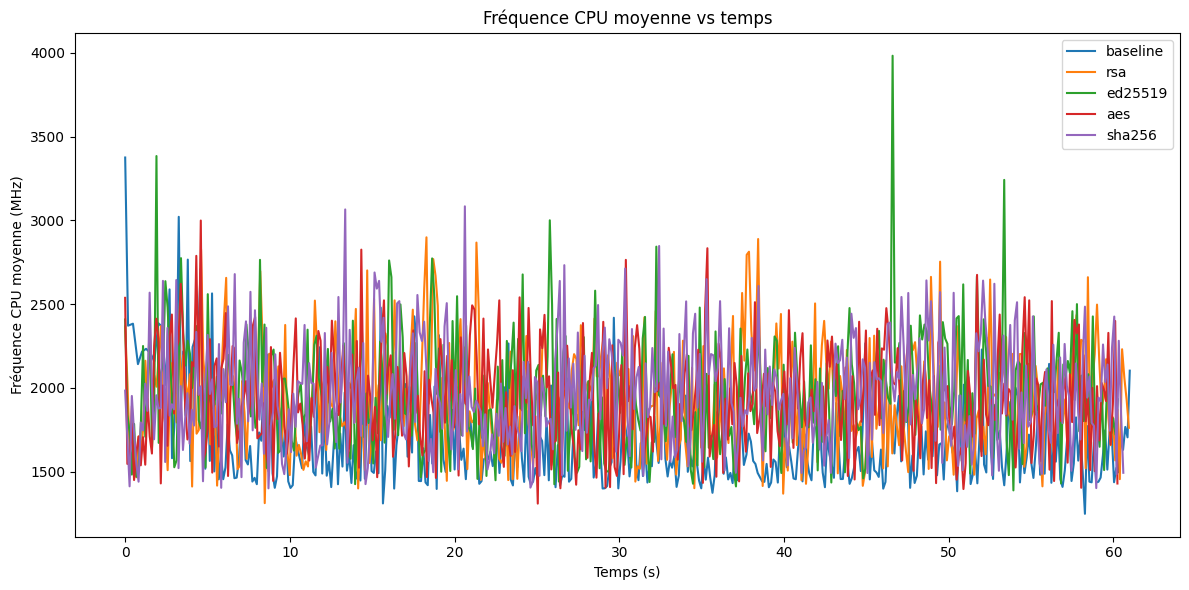

In [6]:
plt.figure()
for name, ts in cpu_timeseries.items():
    plt.plot(ts["t_s"], ts["mean"], label=name)
plt.xlabel("Temps (s)")
plt.ylabel("Fréquence CPU moyenne (MHz)")
plt.title("Fréquence CPU moyenne vs temps")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "01_cpu_mean_vs_time.png", dpi=200)
plt.show()

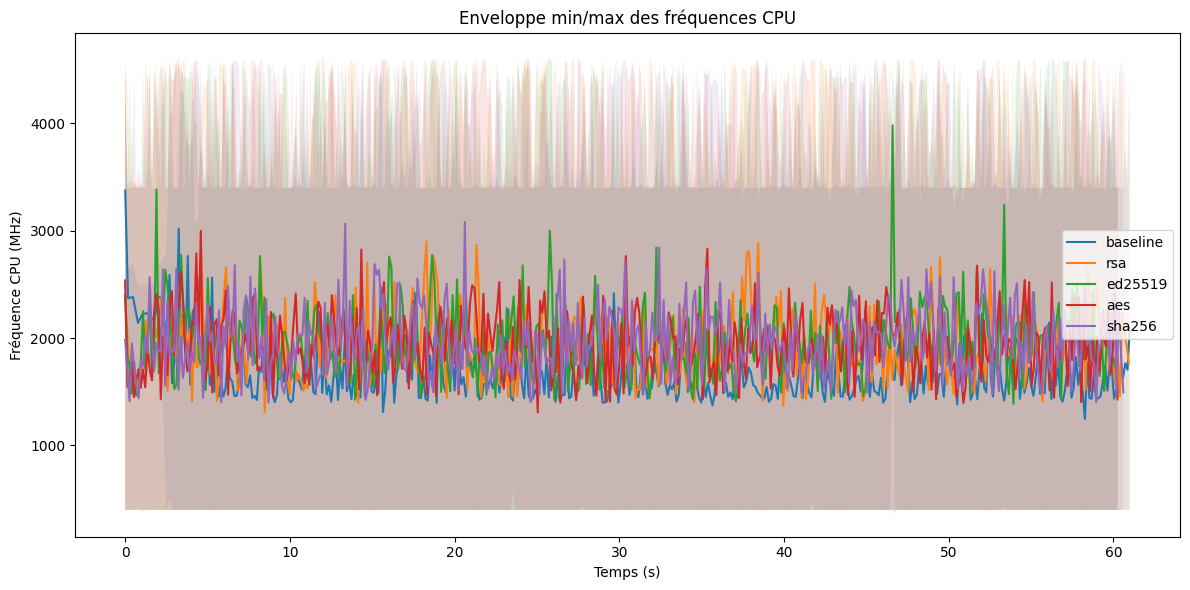

In [7]:
plt.figure()
for name, ts in cpu_timeseries.items():
    plt.plot(ts["t_s"], ts["mean"], label=name)
    plt.fill_between(ts["t_s"], ts["min"], ts["max"], alpha=0.12)
plt.xlabel("Temps (s)")
plt.ylabel("Fréquence CPU (MHz)")
plt.title("Enveloppe min/max des fréquences CPU")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "02_cpu_minmax_envelope.png", dpi=200)
plt.show()

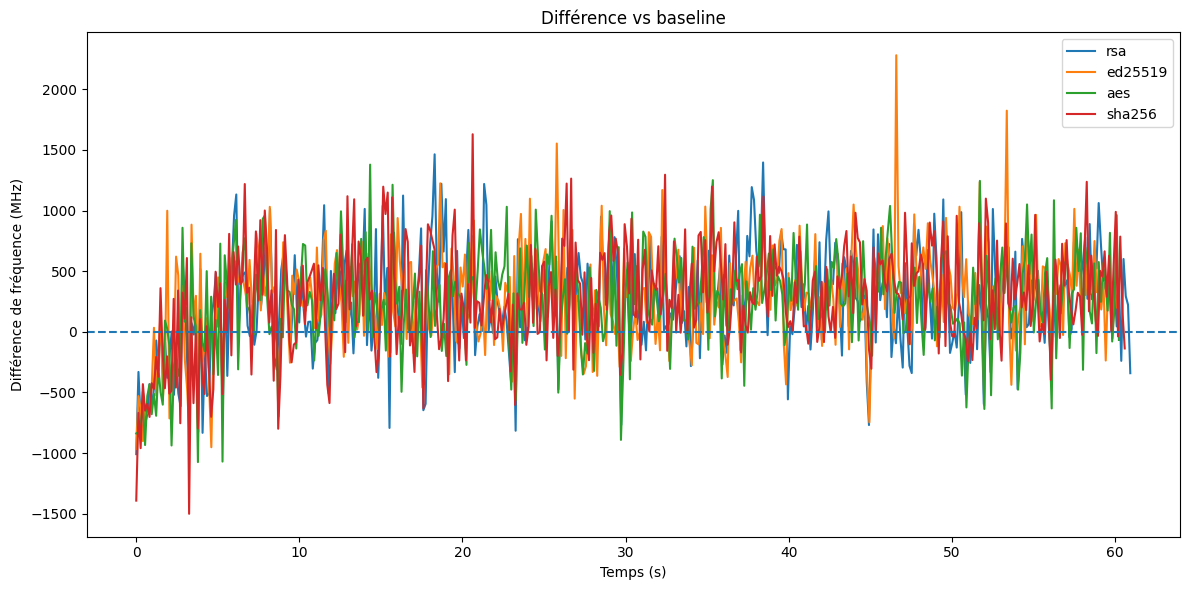

In [8]:
if "baseline" in cpu_timeseries:
    base = cpu_timeseries["baseline"][["t_s", "mean"]].rename(columns={"mean": "baseline_mean"})
    plt.figure()
    for name, ts in cpu_timeseries.items():
        if name == "baseline":
            continue
        merged = pd.merge_asof(
            ts.sort_values("t_s"),
            base.sort_values("t_s"),
            on="t_s",
            direction="nearest"
        )
        diff = merged["mean"] - merged["baseline_mean"]
        plt.plot(merged["t_s"], diff, label=name)
    plt.axhline(0, linestyle="--")
    plt.xlabel("Temps (s)")
    plt.ylabel("Différence de fréquence (MHz)")
    plt.title("Différence vs baseline")
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "03_diff_vs_baseline.png", dpi=200)
    plt.show()

/tmp/ipykernel_104477/4006107892.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showfliers=False)


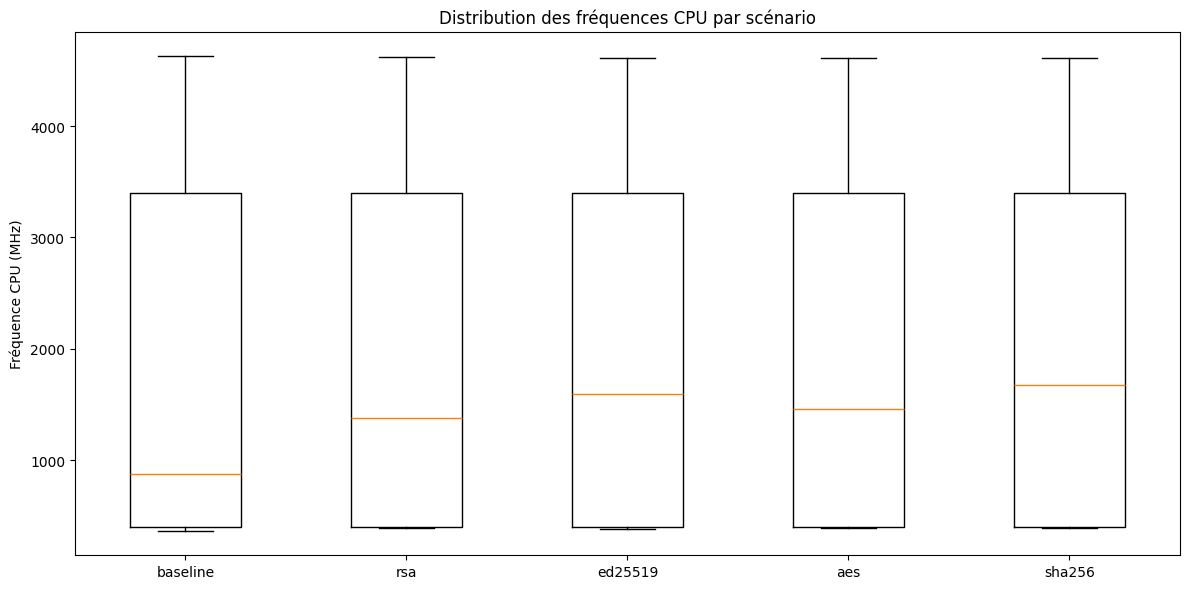

In [9]:
plt.figure()
data = []
labels = []
for name, df in cpu_data.items():
    data.append(df["freq_mhz"].values)
    labels.append(name)
plt.boxplot(data, labels=labels, showfliers=False)
plt.ylabel("Fréquence CPU (MHz)")
plt.title("Distribution des fréquences CPU par scénario")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "04_boxplot_cpu_freq.png", dpi=200)
plt.show()

## 6) Graphes itérations / seconde et durée moyenne

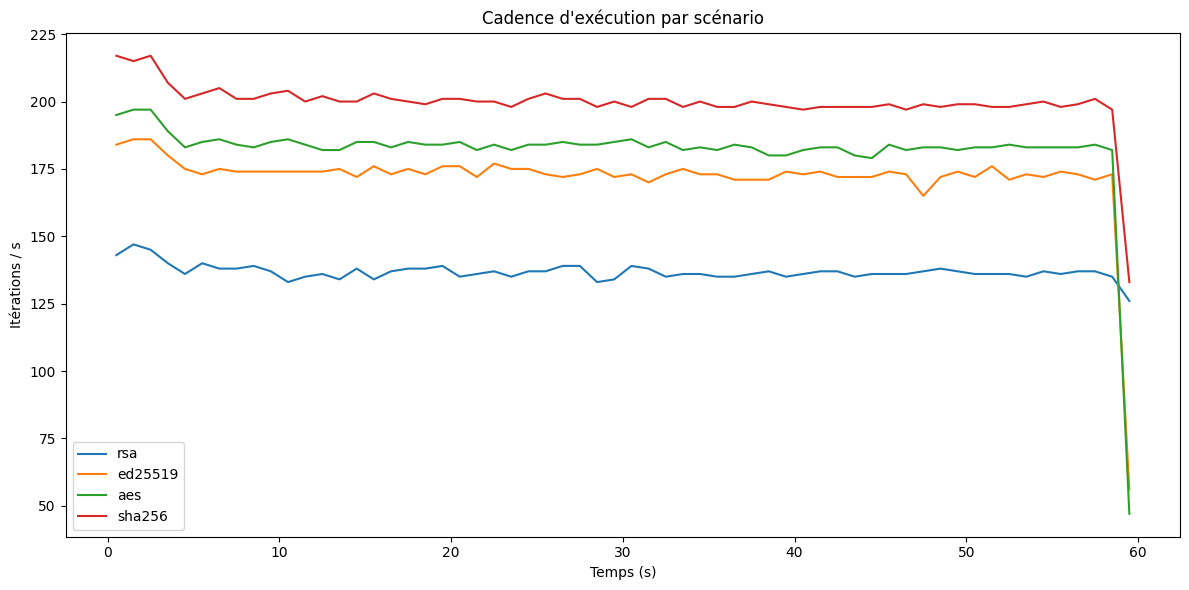

In [10]:
plt.figure()
for name, ips in iter_per_sec.items():
    plt.plot(ips["t_mid_s"], ips["iters_per_sec"], label=name)
plt.xlabel("Temps (s)")
plt.ylabel("Itérations / s")
plt.title("Cadence d'exécution par scénario")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "05_iterations_per_second.png", dpi=200)
plt.show()

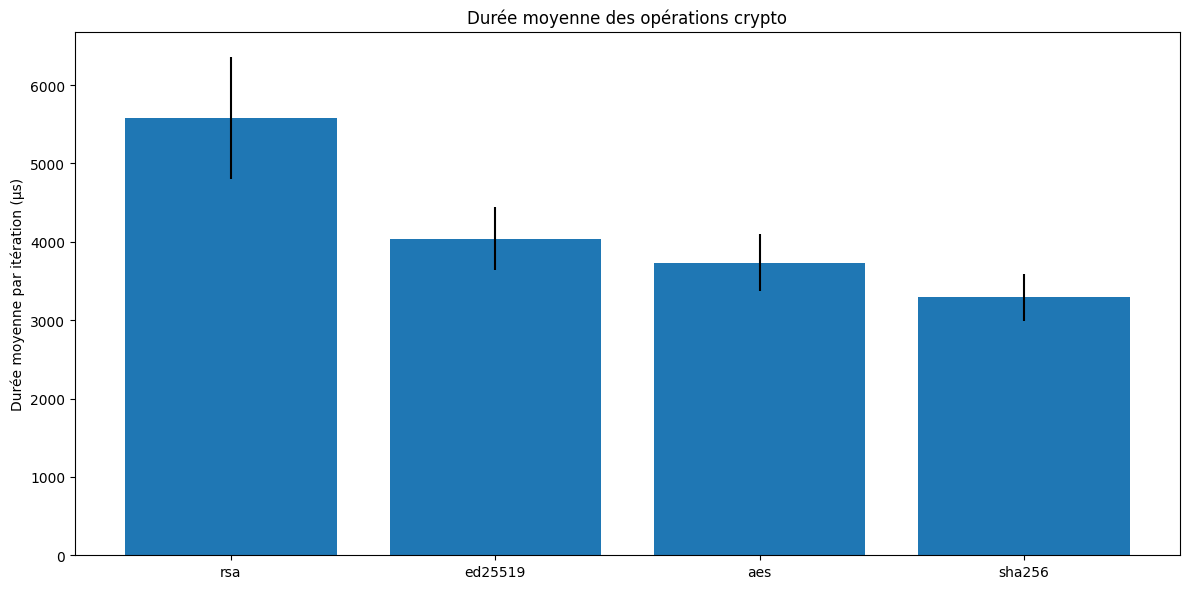

In [11]:
plt.figure()
names = []
means = []
stds = []
for name, g in iter_global.items():
    names.append(name)
    means.append(g["mean_duration_us"])
    stds.append(g["std_duration_us"])
plt.bar(names, means, yerr=stds)
plt.ylabel("Durée moyenne par itération (µs)")
plt.title("Durée moyenne des opérations crypto")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "06_mean_duration_per_iter.png", dpi=200)
plt.show()

## 7) Exports détaillés

In [12]:
for name, df in cpu_core_stats.items():
    df.to_csv(OUTPUT_DIR / f"{name}_cpu_summary_by_core.csv", index=False)
for name, df in cpu_timeseries.items():
    df.to_csv(OUTPUT_DIR / f"{name}_cpu_timeseries_mean.csv", index=False)
for name, df in iter_per_sec.items():
    df.to_csv(OUTPUT_DIR / f"{name}_iters_per_sec.csv", index=False)

with open(OUTPUT_DIR / "global_summary.json", "w") as f:
    json.dump({
        "cpu_global": cpu_global,
        "iter_global": iter_global
    }, f, indent=2)

print(f"[OK] Exports écrits dans {OUTPUT_DIR.resolve()}")

[OK] Exports écrits dans /home/kamilahezzat/Documents/S7/LRE/GIT/crypto_again/output_compare_multi_algo


## 8) Lecture scientifique rapide

Une fois les figures générées, tu peux regarder :
- **RSA** : fréquence plus bursty ? variance plus forte ?
- **Ed25519** : plus compact / moins dispersé ?
- **AES** : profil plus régulier ?
- **SHA-256** : charge très répétitive et cadence élevée ?

Tu peux ensuite conclure sur :
- la **différence de dynamique CPU** entre familles d’algorithmes,
- l’existence de **signatures comportementales indirectes**,
- l’intérêt de comparer ensuite **randomization** et **noise injection**.
